# QCD-era background
Solves T(eta), a(eta), H(eta), w(eta), cs2(eta) from the Saikawa-Shirai g*(T) fits (Almeida & Torrado Eq. 2), and plots them.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../core'))
import numpy as np
import matplotlib.pyplot as plt
import plotstyle; plotstyle.use_latex()
import thermo
import background_qcd as qcd
import jax.numpy as jnp

background_qcd: solving coupled continuity-equation ODE for T(eta), a(eta)...
  norm = 0.9836281477


## g*_rho(T), g*_s(T)

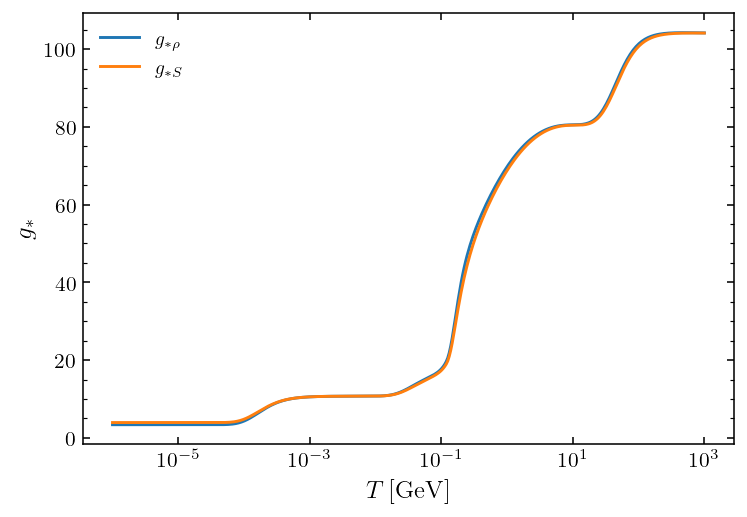

In [2]:
T_GeV = np.geomspace(1e-6, 1e3, 400)
grho, gs = thermo.gstar_gstars(jnp.asarray(T_GeV))
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(T_GeV, grho, label=r'$g_{*\rho}$')
ax.plot(T_GeV, gs, label=r'$g_{*S}$')
ax.set_xscale('log'); ax.set_xlabel(r'$T\,[\mathrm{GeV}]$'); ax.set_ylabel(r'$g_*$')
ax.legend(); plt.show()

## w(eta), cs2(eta): the QCD dip

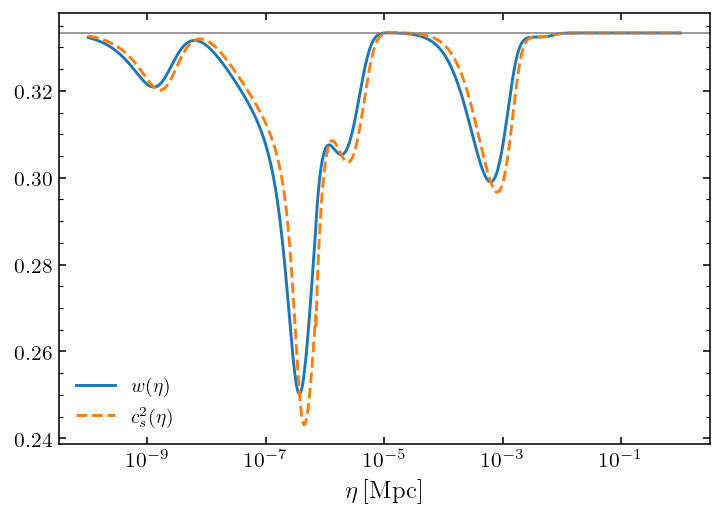

In [3]:
eta = np.geomspace(1e-10, 1.0, 2000)
w = np.asarray(qcd.w_of_eta(jnp.asarray(eta)))
cs2 = np.asarray(qcd.cs2_of_eta(jnp.asarray(eta)))
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(eta, w, label=r'$w(\eta)$')
ax.plot(eta, cs2, label=r'$c_s^2(\eta)$', ls='--')
ax.axhline(1/3, color='gray', lw=0.8)
ax.set_xscale('log'); ax.set_xlabel(r'$\eta\,[\mathrm{Mpc}]$')
ax.legend(); plt.show()

## a(eta), H(eta)

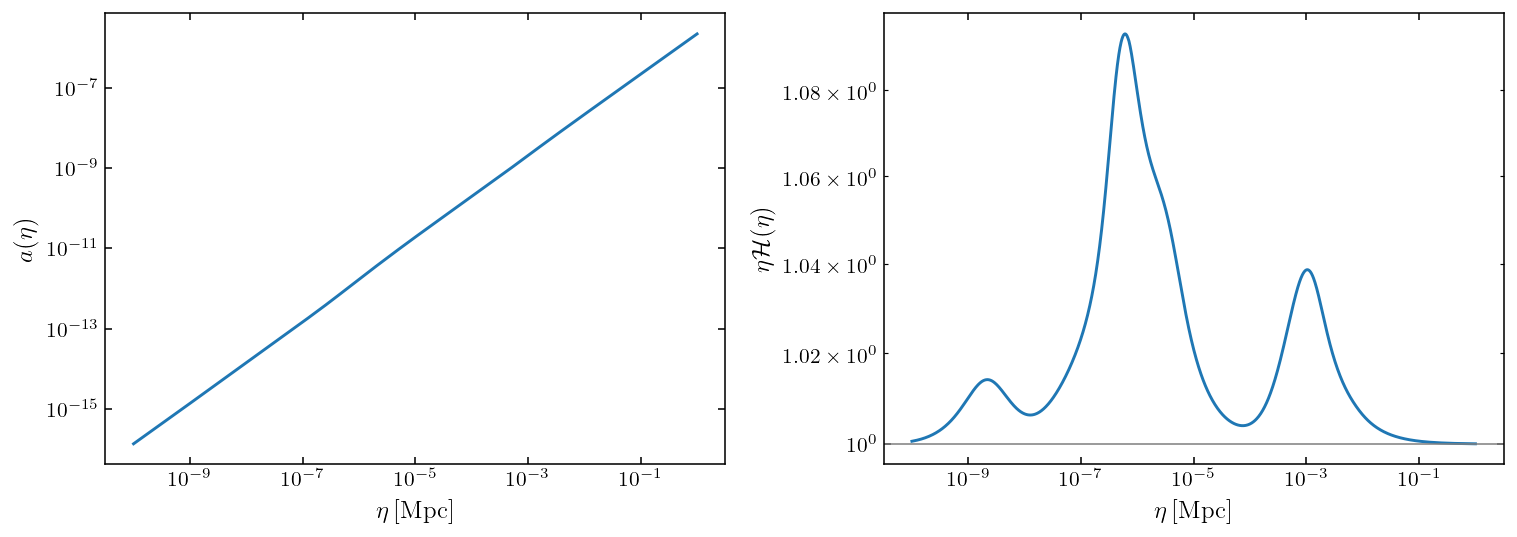

In [4]:
a = np.asarray(qcd.a_of_eta(jnp.asarray(eta)))
H = np.asarray(qcd.H_of_eta(jnp.asarray(eta)))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].loglog(eta, a); axes[0].set_xlabel(r'$\eta\,[\mathrm{Mpc}]$'); axes[0].set_ylabel(r'$a(\eta)$')
axes[1].loglog(eta, eta * H); axes[1].set_xlabel(r'$\eta\,[\mathrm{Mpc}]$'); axes[1].set_ylabel(r'$\eta\mathcal{H}(\eta)$')
axes[1].axhline(1.0, color='gray', lw=0.8)
plt.tight_layout(); plt.show()